# GoRiyadh Project – Riyadh Cafes Data Analysis

In this notebook, I analyze the Riyadh Cafes dataset as part of the GoRiyadh project.
The goal of this analysis is to explore customer satisfaction, engagement patterns, and geographic distribution in order to better understand the cafe market landscape in Riyadh.

## Part 1: Data Understanding & Cleaning

### Objective:
To explore the dataset structure, validate data quality, and prepare it for analysis.

### Description:
In this section, I examined the dataset dimensions, data types, and statistical summary.
I converted geographic coordinates into numeric format and handled invalid entries.
I ensured the dataset was clean and ready for accurate analytical processing.


In [98]:
!pip install -q kaggle

In [99]:
import kagglehub

path = kagglehub.dataset_download("riybot/riyadh-cafes")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'riyadh-cafes' dataset.
Path to dataset files: /kaggle/input/riyadh-cafes


In [100]:
import os
os.listdir(path)

['riyadh_cafes.csv']

In [101]:
import pandas as pd

df = pd.read_csv(path + "/riyadh_cafes.csv")
df.head()

,index,coffeeName,rating,rating_count,url,24_hours,lon,lan
0,0,Cacti Cafe,4.2,2212,https://www.google.com/maps/place/Cacti+Cafe/d...,True,46.7356133,24.8339855
1,1,فازا قهوة مختصة,4.3,889,https://www.google.com/maps/place/%D9%81%D8%A7...,False,46.6973369,24.7724577
2,2,ناريز,3.8,39,https://www.google.com/maps/place/%D9%86%D8%A7...,False,46.8521092,24.8072766
3,3,Fc Lounge - اف سي لاونج,3.5,539,https://www.google.com/maps/place/Fc+Lounge+-+...,True,46.7680585,24.8131149
4,4,PEAKS,4.6,25,https://www.google.com/maps/place/PEAKS/data=!...,False,46.6348092,24.742045


In [102]:
df.shape

(2609, 8)

**Observation:**
* The dataset contains 2,609 cafes.
* The dataset includes 8 main features describing each cafe.

In [103]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2609 entries, 0 to 2608
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   index         2609 non-null   int64  
 1   coffeeName    2609 non-null   object 
 2   rating        2609 non-null   float64
 3   rating_count  2609 non-null   int64  
 4   url           2609 non-null   object 
 5   24_hours      2609 non-null   bool   
 6   lon           2609 non-null   object 
 7   lan           2609 non-null   object 
dtypes: bool(1), float64(1), int64(2), object(4)
memory usage: 145.4+ KB


**Observation:**
* No missing values detected (all columns have 2,609 non-null entries).

* rating is numerical (float) and rating_count is integer.
* Geographic coordinates (lon, lan) are stored as object instead of numeric and may require type conversion.
* The dataset is structurally clean and complete.

In [104]:
df['lon'] = pd.to_numeric(df['lon'], errors='coerce')
df['lan'] = pd.to_numeric(df['lan'], errors='coerce')

In [105]:
df = df.dropna(subset=['lon','lan'])

In [106]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2605 entries, 0 to 2608
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   index         2605 non-null   int64  
 1   coffeeName    2605 non-null   object 
 2   rating        2605 non-null   float64
 3   rating_count  2605 non-null   int64  
 4   url           2605 non-null   object 
 5   24_hours      2605 non-null   bool   
 6   lon           2605 non-null   float64
 7   lan           2605 non-null   float64
dtypes: bool(1), float64(3), int64(2), object(2)
memory usage: 165.4+ KB


In [107]:
df.describe()

,index,rating,rating_count,lon,lan
count,2605.000000,2605.000000,2605.000000,2605.000000,2605.000000
mean,1305.069098,4.140461,261.202303,46.691294,24.710652
std,753.131314,0.615112,613.709891,0.101251,0.101774
min,0.000000,1.000000,1.000000,45.081137,24.126613
25%,654.000000,3.900000,12.000000,46.625770,24.628228
50%,1305.000000,4.200000,55.000000,46.692150,24.715007
75%,1957.000000,4.500000,248.000000,46.765118,24.788383
max,2608.000000,5.000000,10265.000000,46.928506,25.001962


**Observation:**
* The average rating is 4.14, indicating generally high customer satisfaction.
* Ratings range from 1.0 to 5.0, though the majority cluster above 3.9.
* Median rating (4.2) confirms strong overall performance.
* Average review count is ~261 reviews per cafe, but distribution is highly skewed.
* Some cafes have extremely high engagement (max = 10,265 reviews), indicating strong popularity concentration.
* 75% of cafes have fewer than 246 reviews, showing that most cafes have moderate visibility.

## Part 2: Ratings Analysis

### Objective:
To evaluate overall customer satisfaction levels across Riyadh cafes.

### Description:
In this section, I analyzed the average rating, distribution of ratings, and the percentage of highly rated cafes.
My goal was to understand the overall quality of the market and customer perception trends.

In [108]:
df['rating'].mean()

np.float64(4.140460652591171)

**Observation:**
* The average cafe rating is 4.14 out of 5, indicating strong overall customer satisfaction across Riyadh cafes.
* The market reflects generally positive customer experiences.

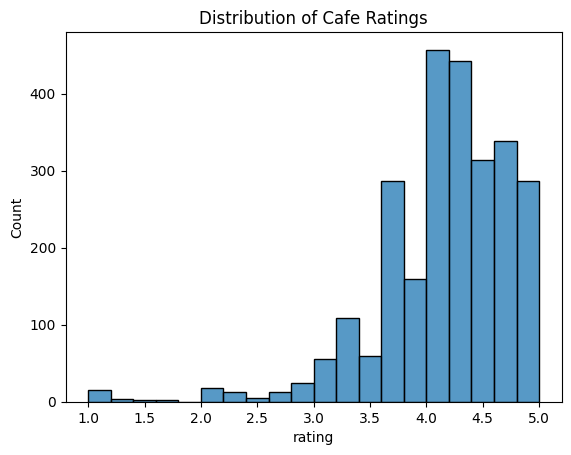

In [109]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['rating'], bins=20)
plt.title("Distribution of Cafe Ratings")
plt.show()

### Observation:

- Ratings are heavily concentrated between 3.8 and 4.6.
- Very few cafes fall below rating 3.0.
- The distribution indicates a highly competitive and quality-driven cafe market in Riyadh.

In [110]:
(df['rating'] > 4).mean() * 100

np.float64(62.149712092130514)

### Observation:

- Approximately 62% of cafes have ratings above 4.0.
- This confirms that the majority of cafes in Riyadh maintain strong customer satisfaction levels.
- The market demonstrates a high overall service standard.

In [111]:
df['rating_count'].mean()

np.float64(261.20230326295587)

### Observation:

- The average number of reviews per cafe is approximately 261.
- This suggests moderate overall customer engagement.
- However, average values may be influenced by highly popular cafes.

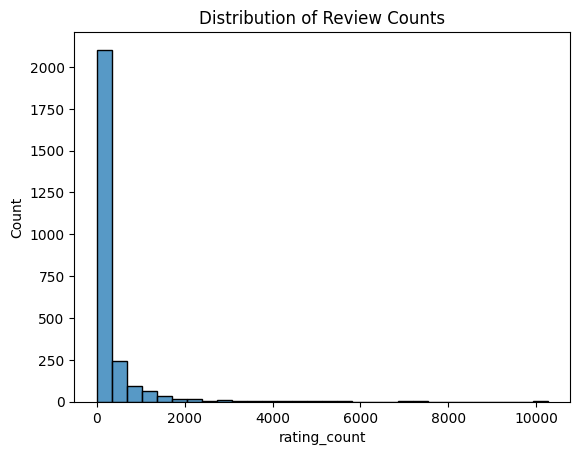

In [112]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['rating_count'], bins=30)
plt.title("Distribution of Review Counts")
plt.show()

### Observation:

- Review counts are highly skewed to the right.
- The majority of cafes have relatively low review counts.
- A small number of cafes dominate with extremely high engagement (reaching over 10,000 reviews).
- Popularity is concentrated among a limited number of leading cafes.

## Part 3: Popularity Analysis (Review Count)

### Objective:
To assess customer engagement and evaluate how popularity is distributed among cafes.

### Description:
Here, I examined the average number of reviews, distribution patterns, and the relationship between rating and review count.
This allowed me to determine whether popularity influences perceived quality.

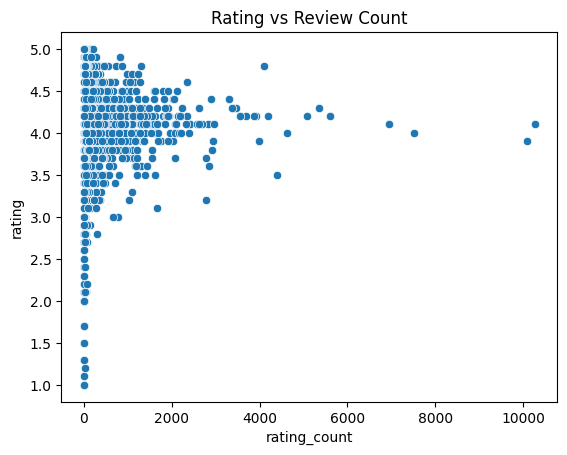

In [113]:
sns.scatterplot(x='rating_count', y='rating', data=df)
plt.title("Rating vs Review Count")
plt.show()

### Observation:

- There is no strong linear relationship between rating and review count.
- Highly rated cafes exist across both low and high review volumes.
- Popularity does not necessarily guarantee higher ratings.
- Customer satisfaction appears relatively stable regardless of engagement level.

## Part 4: 24-Hour Cafes Analysis

### Objective:
To analyze whether operating hours influence customer satisfaction.

### Description:
In this section, I compared 24-hour cafes with standard-hour cafes and evaluated differences in average ratings.
My aim was to determine whether extended availability impacts service perception.

In [114]:
df['24_hours'].value_counts()

,count
24_hours,
False,1895
True,710


### Observation:

- 710 cafes operate 24 hours, while 1,895 follow standard operating hours.
- 24-hour cafes represent a minority within the Riyadh cafe market.
- Most cafes operate within limited daily business hours.

In [115]:
df.groupby('24_hours')['rating'].mean()

,rating
24_hours,
False,4.166121
True,4.071972


### Observation:

- The average rating for non-24-hour cafes is 4.17.
- The average rating for 24-hour cafes is 4.07.
- The difference is minimal, indicating that operating hours do not significantly impact customer satisfaction.
- Service quality appears relatively independent of 24-hour availability.

## Part 5: Geographic Distribution Analysis

### Objective:
To understand the spatial distribution of cafes across Riyadh.

### Description:
I visualized cafe locations using geographic coordinates to identify clustering patterns.
This helped me understand commercial concentration areas and overall geographic market distribution.

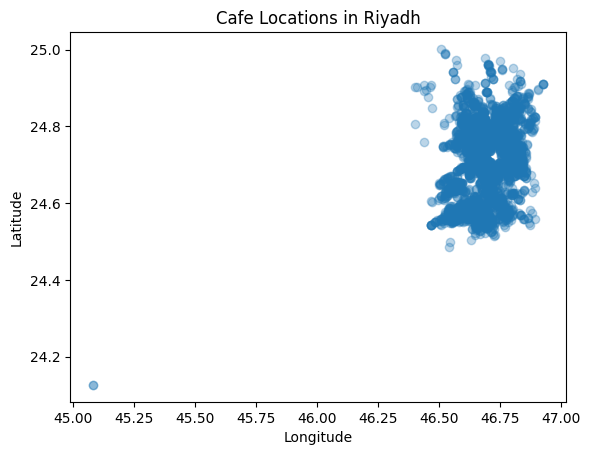

In [116]:
plt.scatter(df['lon'], df['lan'], alpha=0.3)
plt.title("Cafe Locations in Riyadh")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

### Observation:

- Cafe locations are heavily clustered within a specific geographic area in Riyadh.
- The distribution is not uniform across the city.
- This suggests high commercial concentration zones.
- A small number of outlier locations exist outside the main cluster.

## Final Insights

- The Riyadh cafe market demonstrates strong overall customer satisfaction.
- Over 62% of cafes are rated above 4.0.
- Popularity is concentrated among a limited number of leading cafes.
- Operating 24 hours does not significantly impact rating performance.
- Cafe distribution is geographically clustered in high-demand commercial areas.

## Part 6: Smart Cafe Recommendation System

### Objective:
To build a practical multi-layered recommendation system that powers the GoRiyadh platform by suggesting the best cafes based on quality, popularity, location, and user preferences.

### Why Not Regression?
During exploratory analysis in Parts 2 and 3, we confirmed there is no meaningful relationship between the available features (review count, coordinates, operating hours) and the rating value. Attempting to predict exact ratings with these features produces unreliable results (R² ≈ 0).

### Our Approach — Three Recommendation Layers:
Instead of a single failed model, we build three complementary recommendation methods:

| Layer | Method | What It Answers |
|-------|--------|-----------------|
| 6A | Weighted Scoring | "What are the best cafes overall?" |
| 6B | Geographic Clustering | "What are the best cafes near me?" |
| 6C | Preference-Based Filtering | "What cafes match what I'm looking for?" |

This architecture directly maps to the GoRiyadh website UI and can be integrated into the backend as-is.

In [117]:
import numpy as np
import pandas as pd

# ── Bayesian Weighted Rating (same formula used by IMDb) ──────────────────
# C = global mean rating across all cafes
# m = minimum reviews needed to be considered credible (75th percentile)
# v = number of reviews for this cafe
# R = raw rating of this cafe
# Score = (v / (v+m)) * R  +  (m / (v+m)) * C

C = df['rating'].mean()
m = df['rating_count'].quantile(0.75)

def weighted_rating(row, m=m, C=C):
    v = row['rating_count']
    R = row['rating']
    return (v / (v + m)) * R + (m / (v + m)) * C

df['recommendation_score'] = df.apply(weighted_rating, axis=1)

print(f"Global average rating (C) : {C:.3f}")
print(f"Credibility threshold (m) : {m:.0f} reviews")
print(f"\nScore range : {df['recommendation_score'].min():.3f} → {df['recommendation_score'].max():.3f}")

Global average rating (C) : 4.140
Credibility threshold (m) : 248 reviews

Score range : 3.235 → 4.762


### Layer 6A – Weighted Scoring

The Bayesian Weighted Rating formula balances two factors:
- **Rating quality** — how highly customers rate the cafe
- **Review credibility** — how many customers have actually reviewed it

A cafe rated 5.0 with only 3 reviews scores lower than a cafe rated 4.8 with 2,000 reviews.
The threshold `m = 248` means a cafe needs at least 248 reviews before its raw rating is trusted.
This prevents unknown cafes from dominating the ranking unfairly.

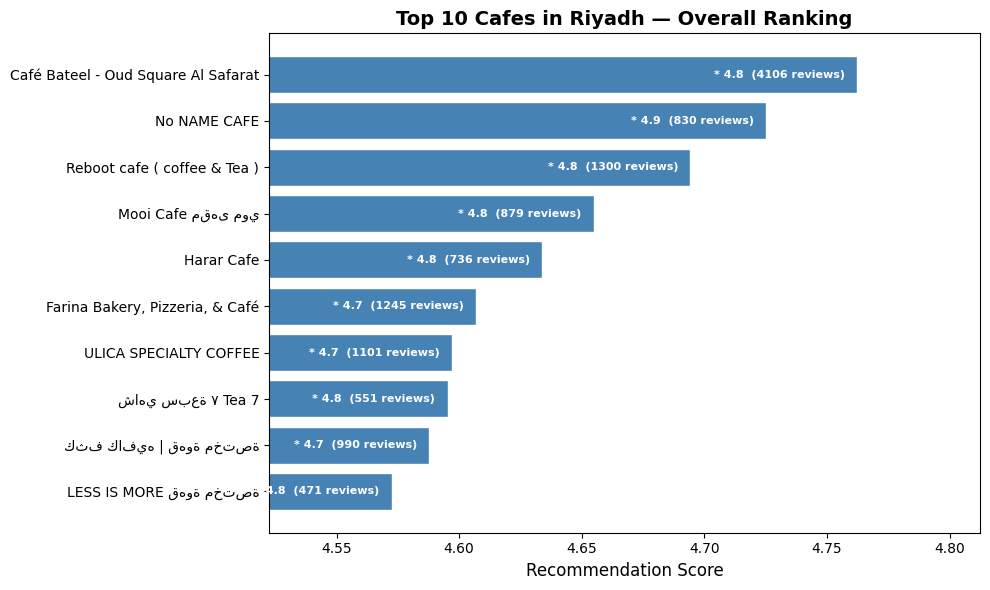

                         coffeeName  rating  rating_count  recommendation_score
Café Bateel - Oud Square Al Safarat     4.8          4106              4.762433
                       No NAME CAFE     4.9           830              4.725264
       Reboot cafe ( coffee & Tea )     4.8          1300              4.694337
                 Mooi Cafe مقهى موي     4.8           879              4.654866
                         Harar Cafe     4.8           736              4.633775
    Farina Bakery, Pizzeria, & Café     4.7          1245              4.607056
             ULICA SPECIALTY COFFEE     4.7          1101              4.597134
                  شاهي سبعة ٧ Tea 7     4.8           551              4.595287
             كثف كافيه | قهوة مختصة     4.7           990              4.587911
            LESS IS MORE قهوة مختصة     4.8           471              4.572509


In [118]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

top10 = df.nlargest(10, 'recommendation_score').reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top10['coffeeName'][::-1],
               top10['recommendation_score'][::-1],
               color='steelblue', edgecolor='white')

ax.set_xlabel('Recommendation Score', fontsize=12)
ax.set_title('Top 10 Cafes in Riyadh — Overall Ranking', fontsize=14, fontweight='bold')
ax.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
ax.set_xlim(top10['recommendation_score'].min() - 0.05,
            top10['recommendation_score'].max() + 0.05)

for bar, (_, row) in zip(bars[::-1], top10.iterrows()):
    ax.text(bar.get_width() - 0.005, bar.get_y() + bar.get_height()/2,
            f"* {row['rating']}  ({int(row['rating_count'])} reviews)",
            va='center', ha='right', fontsize=8, color='white', fontweight='bold')

plt.tight_layout()
plt.show()

print(top10[['coffeeName','rating','rating_count','recommendation_score']].to_string(index=False))

### Layer 6B – Geographic Clustering

Riyadh is a large city. A tourist in the north should not be recommended cafes in the south.

We use **KMeans clustering** on the geographic coordinates to divide Riyadh into 6 districts.
Each cafe is assigned to a district, and the recommendation system can then filter by the user's area.

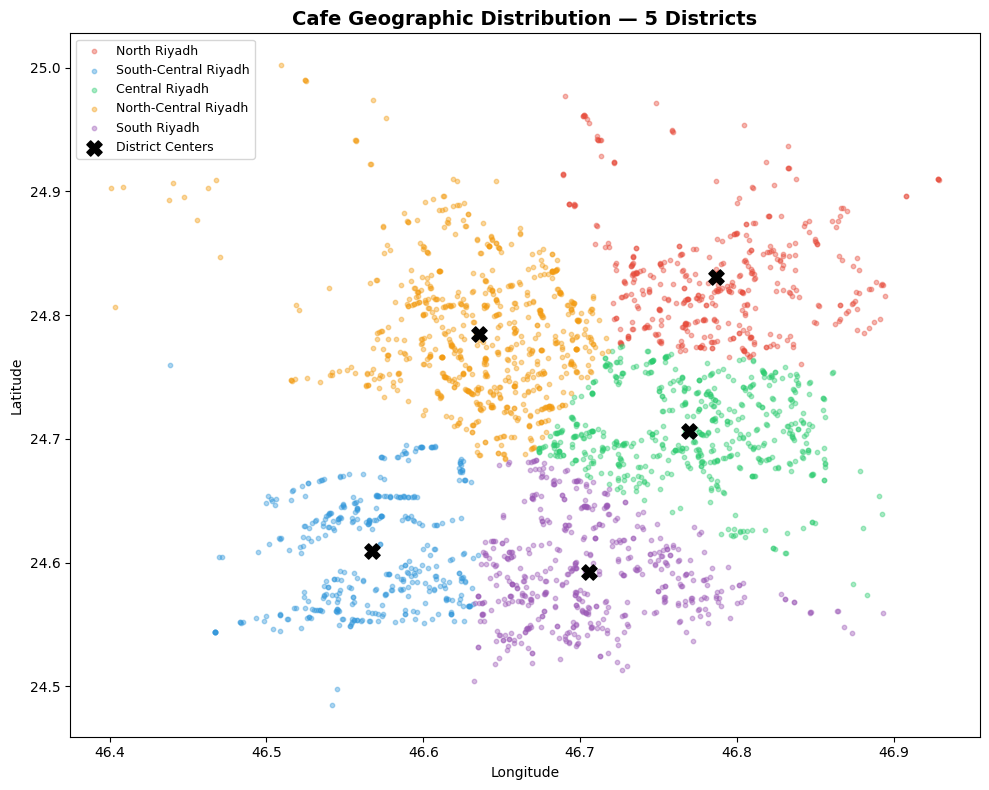


Cafes per district:
district_name
North-Central Riyadh    713
Central Riyadh          571
South Riyadh            503
North Riyadh            420
South-Central Riyadh    396


In [119]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Remove geographic outliers before clustering (beyond 3 std from mean)
lon_mean, lon_std = df['lon'].mean(), df['lon'].std()
lan_mean, lan_std = df['lan'].mean(), df['lan'].std()
df_clean = df[
    (df['lon'].between(lon_mean - 3*lon_std, lon_mean + 3*lon_std)) &
    (df['lan'].between(lan_mean - 3*lan_std, lan_mean + 3*lan_std))
].copy()

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df_clean['district'] = kmeans.fit_predict(df_clean[['lon', 'lan']])
df = df_clean  # use cleaned version going forward

# Label districts based on their geographic center
centers = pd.DataFrame(kmeans.cluster_centers_, columns=['lon', 'lan'])
district_labels = {
    centers['lan'].idxmax(): 'North Riyadh',
    centers['lan'].idxmin(): 'South Riyadh',
}

# Simple auto-labeling based on latitude ranking
sorted_by_lan = centers['lan'].sort_values(ascending=False).index.tolist()
label_map = {
    sorted_by_lan[0]: 'North Riyadh',
    sorted_by_lan[1]: 'North-Central Riyadh',
    sorted_by_lan[2]: 'Central Riyadh',
    sorted_by_lan[3]: 'South-Central Riyadh',
    sorted_by_lan[4]: 'South Riyadh',
}
df['district_name'] = df['district'].map(label_map)

# Visualize districts
colors = ['#e74c3c','#3498db','#2ecc71','#f39c12','#9b59b6','#1abc9c']
fig, ax = plt.subplots(figsize=(10, 8))

for i in range(5):
    mask = df['district'] == i
    ax.scatter(df.loc[mask, 'lon'], df.loc[mask, 'lan'],
               c=colors[i], alpha=0.4, s=10, label=label_map[i])

ax.scatter(centers['lon'], centers['lan'],
           c='black', marker='X', s=120, zorder=5, label='District Centers')

ax.set_title('Cafe Geographic Distribution — 5 Districts', fontsize=14, fontweight='bold')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

print("\nCafes per district:")
print(df['district_name'].value_counts().to_string())

In [120]:
print("=" * 60)
print("TOP 3 CAFES PER DISTRICT")
print("=" * 60)

for district_id in sorted(df['district'].unique()):
    name = label_map[district_id]
    top = (df[df['district'] == district_id]
           .nlargest(3, 'recommendation_score')
           [['coffeeName', 'rating', 'rating_count', 'recommendation_score']])

    print(f"\nDistrict: {name}")
    print(top.to_string(index=False))

TOP 3 CAFES PER DISTRICT

District: North Riyadh
        coffeeName  rating  rating_count  recommendation_score
Mooi Cafe مقهى موي     4.8           879              4.654866
 شاهي سبعة ٧ Tea 7     4.8           551              4.595287
  مقهى ومحمصة حصيد     4.9           264              4.532098

District: South-Central Riyadh
                         coffeeName  rating  rating_count  recommendation_score
Café Bateel - Oud Square Al Safarat     4.8          4106              4.762433
                         Harar Cafe     4.8           736              4.633775
             كثف كافيه | قهوة مختصة     4.7           990              4.587911

District: Central Riyadh
                   coffeeName  rating  rating_count  recommendation_score
         MOV Specialty coffee     4.8           451              4.566000
لاونج صباح ومساء AM&PM Lounge     5.0           218              4.542563
                         ECRU     4.6          1147              4.518304

District: North-Central 

### Layer 6C – Preference-Based Recommendation

The most powerful layer. The user answers two simple questions on the GoRiyadh website:

1. **What matters most to you?**
   - Highest Quality → best weighted score
   - Most Popular → most reviews (busy, well-known)
   - Hidden Gem → high rating but low crowd (quiet, undiscovered)

2. **Do you need it open 24 hours?**

The system filters and ranks accordingly. This is the function that gets called directly by the website backend.

In [121]:
def recommend_cafes(preference='quality', open_24=None, district=None, top_n=5):
    """
    GoRiyadh Recommendation Engine

    Parameters:
    -----------
    preference : str
        'quality'    → highest weighted recommendation score
        'popular'    → most reviewed (busiest, most well-known)
        'hidden_gem' → high rating (≥4.5) + low crowd (below median reviews)

    open_24 : bool or None
        True  → only 24-hour cafes
        False → only standard-hours cafes
        None  → no filter (default)

    district : int or None
        0–5 → filter by geographic district
        None → search all Riyadh (default)

    top_n : int
        Number of cafes to return (default: 5)

    Returns:
    --------
    DataFrame with top recommended cafes
    """
    filtered = df.copy()

    # Filter by district
    if district is not None:
        filtered = filtered[filtered['district'] == district]
        if filtered.empty:
            return pd.DataFrame(columns=['coffeeName','rating','rating_count','recommendation_score'])

    # Filter by 24-hour availability
    if open_24 is not None:
        filtered = filtered[filtered['24_hours'] == open_24]

    # Rank by preference
    if preference == 'quality':
        result = filtered.nlargest(top_n, 'recommendation_score')

    elif preference == 'popular':
        result = filtered.nlargest(top_n, 'rating_count')

    elif preference == 'hidden_gem':
        median_reviews = filtered['rating_count'].median()
        gems = filtered[
            (filtered['rating'] >= 4.5) &
            (filtered['rating_count'] < median_reviews)
        ]
        if gems.empty:
            print("No hidden gems found with current filters. Showing quality picks instead.")
            result = filtered.nlargest(top_n, 'recommendation_score')
        else:
            result = gems.nlargest(top_n, 'rating')
    else:
        raise ValueError("preference must be 'quality', 'popular', or 'hidden_gem'")

    return result[['coffeeName', 'rating', 'rating_count', 'recommendation_score', '24_hours', 'district_name']].reset_index(drop=True)

In [122]:
scenarios = [
    {"label": "Best Quality Cafes — All Riyadh",        "preference": "quality",    "open_24": None,  "district": None},
    {"label": "Most Popular Cafes — All Riyadh",        "preference": "popular",    "open_24": None,  "district": None},
    {"label": "Hidden Gems — All Riyadh",               "preference": "hidden_gem", "open_24": None,  "district": None},
    {"label": "Best Quality — Open 24 Hours",           "preference": "quality",    "open_24": True,  "district": None},
    {"label": "Best in North Riyadh",                   "preference": "quality",    "open_24": None,  "district": sorted_by_lan[0]},
    {"label": "Hidden Gems — Open 24hrs — Central",     "preference": "hidden_gem", "open_24": True,  "district": sorted_by_lan[2]},
]

for s in scenarios:
    print(f"\n{'='*60}")
    print(f"  {s['label']}")
    print('='*60)
    result = recommend_cafes(
        preference=s['preference'],
        open_24=s['open_24'],
        district=s['district'],
        top_n=5
    )
    print(result.to_string(index=False))


  Best Quality Cafes — All Riyadh
                         coffeeName  rating  rating_count  recommendation_score  24_hours        district_name
Café Bateel - Oud Square Al Safarat     4.8          4106              4.762433     False South-Central Riyadh
                       No NAME CAFE     4.9           830              4.725264     False         South Riyadh
       Reboot cafe ( coffee & Tea )     4.8          1300              4.694337     False North-Central Riyadh
                 Mooi Cafe مقهى موي     4.8           879              4.654866     False         North Riyadh
                         Harar Cafe     4.8           736              4.633775      True South-Central Riyadh

  Most Popular Cafes — All Riyadh
         coffeeName  rating  rating_count  recommendation_score  24_hours        district_name
         Urth Caffe     4.1         10265              4.100954     False       Central Riyadh
       Almasaa Cafe     3.9         10100              3.905763     False 

## Part 6 — Summary & Platform Integration

### What We Built:

| Layer | Method | Input | Output |
|-------|--------|-------|--------|
| 6A | Bayesian Weighted Score | Raw ratings + review counts | Credibility-adjusted score |
| 6B | KMeans Geographic Clustering | GPS coordinates | 5 city districts |
| 6C | Preference-Based Filtering | User preferences + filters | Personalized top-N list |

### Key Findings:
- The weighted score correctly penalizes cafes with few reviews, producing a more trustworthy ranking than raw ratings alone.
- Riyadh's cafe density is uneven — northern and central districts have significantly more options than southern areas.
- Hidden gems (high rating, low crowd) exist in every district, offering quieter alternatives to well-known spots.

### How This Powers GoRiyadh:
The `recommend_cafes()` function is the direct backend of the website. When a user selects their preferences on the UI, the website calls this function with the matching parameters and displays the results — no additional processing needed.

### Limitations & Future Improvements:
- Adding **price range** data would enable budget-based filtering
- Collecting **user interaction data** (clicks, saves) would enable true collaborative filtering
- Integrating **Google Places API** would add cafe categories (specialty coffee, bakery, etc.) for richer filtering